# Codesign: sequential per-token morphology generator (full ant)

Report for `experiments/ant_codesign.py`. Combined PPO control + a **sequential token-at-a-time PPG**
generator (ADR-0012). The generator builds a body one token at a time (random slot order, each slot
conditioned on the committed ones) and is rewarded by the body quality `R = V1.0(s0)` from the control
**V1.0 head** — not the raw return. **Gate:** per-leg presence climbs base `[1,4,6]` -> ~all-8, fast and
stable, and the **per-token marginal value** is positive for useful legs (no leg/energy cost yet, so more
legs => more return).

X axis is **epochs**. The dashed line marks the **pretrain->RL handoff** (generator switches from
imitating base±flip to optimizing `R`) — the inflection where presence reverses and climbs. Generator
metrics (`gen/*`, `gen_marg/*`) are logged once per resample window, so they begin sparse.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

D = np.load(Path('../data/ant_codesign/curves.npz'))
seeds = list(D['seeds'])
legs = [str(l) for l in D['legs']]
BASE = {'F', 'BR', 'BL'}            # base morph [1,4,6]

def series(seed, tag):
    k = f"s{seed}__{tag.replace('/', '_')}"
    return D[k + '__step'], D[k + '__val']

# X axis in EPOCHS. TB logs a global frame counter (num_actors*horizon per epoch); rewards/step is
# logged every epoch, so consecutive step deltas give frames/epoch directly (no config needed).
_mr_step, _ = series(seeds[0], 'rewards/step')
FRAMES_PER_EPOCH = int(np.median(np.diff(_mr_step)))
to_epoch = lambda step: np.asarray(step) / FRAMES_PER_EPOCH

# Pretrain->RL handoff: first window where the generator fraction reaches 1.0 (return-driven on).
_gf_step, _gf_val = series(seeds[0], 'gen/fraction')
RL_ONSET = float(to_epoch(_gf_step[np.argmax(_gf_val >= 1.0)]))
# Resample-window length in epochs (generator logs once per window: R_mean is logged every window).
_gv_step, _ = series(seeds[0], 'gen/R_mean')
WINDOW_EPOCHS = max(1, int(round(np.median(np.diff(to_epoch(_gv_step))))))
print(f'seeds: {seeds} | frames/epoch: {FRAMES_PER_EPOCH} | pretrain->RL @ epoch {RL_ONSET:.0f} '
      f'| window ~{WINDOW_EPOCHS} epochs')

def smooth(y, w):
    """Centered rolling mean, edge-normalized (no end droop)."""
    y = np.asarray(y, float)
    if w is None or w <= 1 or len(y) < 2:
        return y
    k = np.ones(min(w, len(y)))
    return np.convolve(y, k, 'same') / np.convolve(np.ones_like(y), k, 'same')

def band(ax, tag, smooth_w=None, **kw):
    """Mean (+min/max band over seeds) of a tag vs EPOCH, optionally rolling-smoothed."""
    xs, ys = [], []
    for s in seeds:
        try:
            x, y = series(s, tag)
        except KeyError:
            continue
        xs.append(x); ys.append(y)
    if not ys:
        return
    m = min(len(a) for a in ys)
    x = to_epoch(xs[0][:m]); Y = np.stack([a[:m] for a in ys])
    ax.plot(x, smooth(Y.mean(0), smooth_w), **kw)
    if len(ys) > 1:
        ax.fill_between(x, smooth(Y.min(0), smooth_w), smooth(Y.max(0), smooth_w),
                        alpha=0.15, color=kw.get('color'))

def mark_rl(ax):
    """Dashed line + label at the pretrain->RL handoff (the presence inflection)."""
    ax.axvline(RL_ONSET, color='k', lw=1.0, ls='--', alpha=0.7)
    ax.text(RL_ONSET, 0.99, ' pretrain→RL', transform=ax.get_xaxis_transform(),
            va='top', ha='left', fontsize=8)

seeds: [np.int64(42)] | frames/epoch: 65536 | pretrain->RL @ epoch 503 | window ~63 epochs


## 1. Per-leg presence probability — the gate

Base legs (F, BR, BL) bold; all eight should rise toward 1.0 after the pretrain->RL handoff.

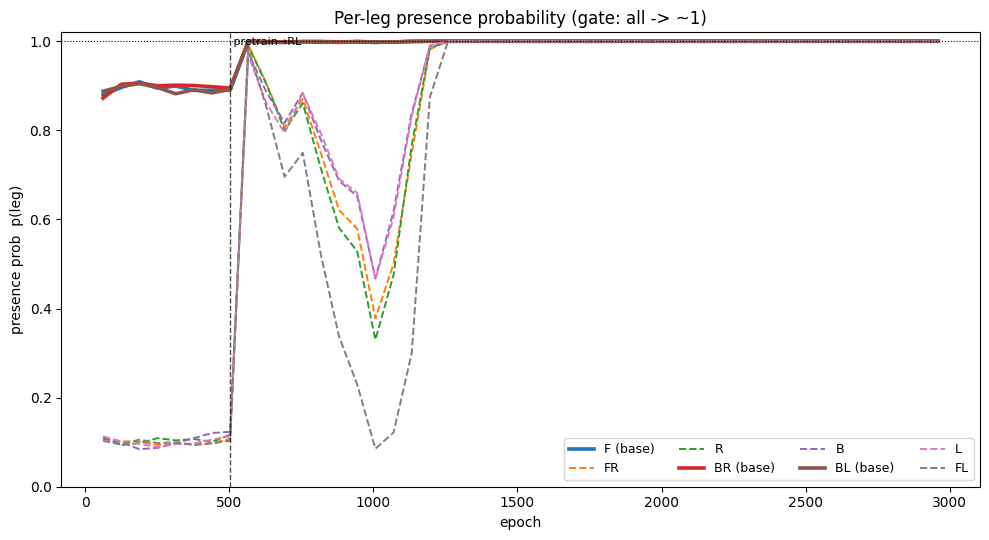

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))
cmap = plt.cm.tab10
for i, leg in enumerate(legs):
    base = leg in BASE
    band(ax, f'gen_p/{leg}', color=cmap(i), lw=2.6 if base else 1.4,
         ls='-' if base else '--', label=f"{leg}{' (base)' if base else ''}")
ax.axhline(1.0, color='k', lw=0.8, ls=':')
ax.set(xlabel='epoch', ylabel='presence prob  p(leg)', ylim=(0, 1.02),
       title='Per-leg presence probability (gate: all -> ~1)')
mark_rl(ax)
ax.legend(ncol=4, fontsize=9); fig.tight_layout()

## 2. Mean leg count

`built/mean_legcount` = the bodies actually built each window (includes the pretrain base±flip ramp;
in the RL phase this equals the generator's per-slot rate summed). Should climb base(~3) -> ~8.

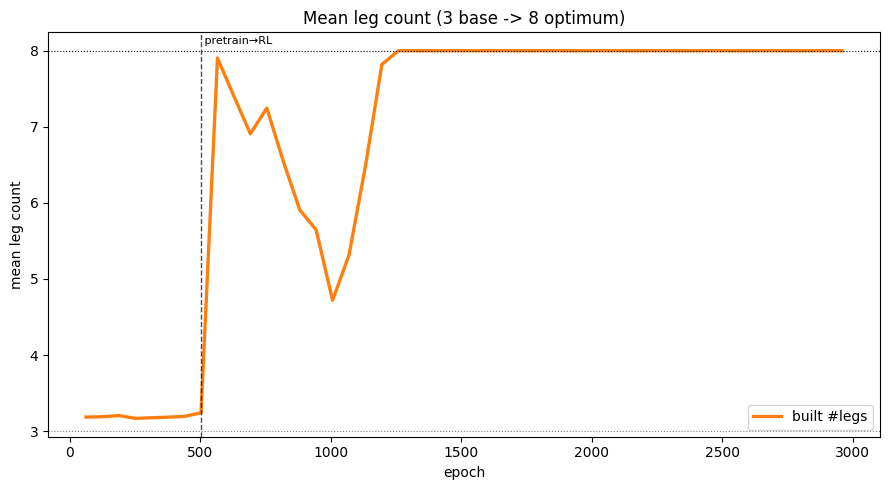

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
band(ax, 'built/mean_legcount', color='C1', lw=2.4, label='built #legs')
ax.axhline(8, color='k', lw=0.8, ls=':'); ax.axhline(3, color='gray', lw=0.8, ls=':')
ax.set(xlabel='epoch', ylabel='mean leg count', title='Mean leg count (3 base -> 8 optimum)')
mark_rl(ax)
ax.legend(); fig.tight_layout()

## 3. Per-token marginal value per leg — the headline

`gen_marg/{leg}` = the generator's own estimate of the value added by turning leg *k* on, in
`R = V1.0(s0)` units (the raw telescoping advantage `v(prefix+leg) - v(prefix)` averaged over the
window's `on` decisions). **This is the per-token marginal-value credit that escapes ADR-0010's
body-agnostic-baseline trap.** RL-phase only (no advantages during pretrain), so it starts at the
handoff; a leg's curve drops out once that leg is always-on (no `on` decision left to measure).
**Gate: positive for every useful leg.**

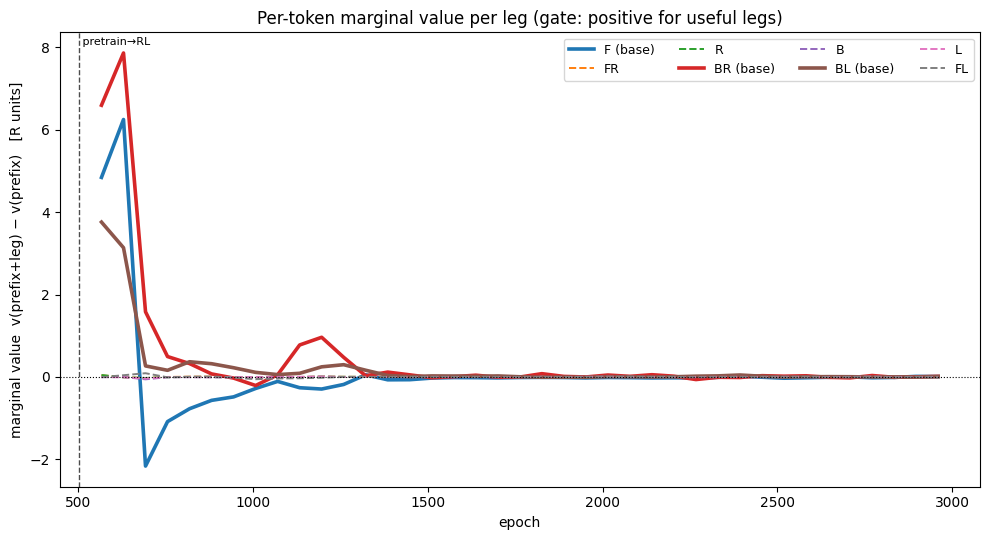

In [15]:
fig, ax = plt.subplots(figsize=(10, 5.5))
cmap = plt.cm.tab10
for i, leg in enumerate(legs):
    base = leg in BASE
    band(ax, f'gen_marg/{leg}', color=cmap(i), lw=2.6 if base else 1.4,
         ls='-' if base else '--', label=f"{leg}{' (base)' if base else ''}")
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.set(xlabel='epoch', ylabel='marginal value  v(prefix+leg) − v(prefix)   [R units]',
       title='Per-token marginal value per leg (gate: positive for useful legs)')
mark_rl(ax)
ax.legend(ncol=4, fontsize=9); fig.tight_layout()

## 4. Body quality `R = V1.0(s0)` and the generator value fit

`gen/R_mean` = mean body quality the generator is rewarded by (the windowed control-V1.0 read on the
reset states). `gen/value_R_corr` = corr of the generator's terminal value `v(full)` with `R` across
envs — the PPG distillation fit (-> 1 as the aux value learns `R`). The scatter is the final window's
per-env `v(full)` vs `R` (`gen_scatter.npz`); points on `y=x` mean the generator value is calibrated.

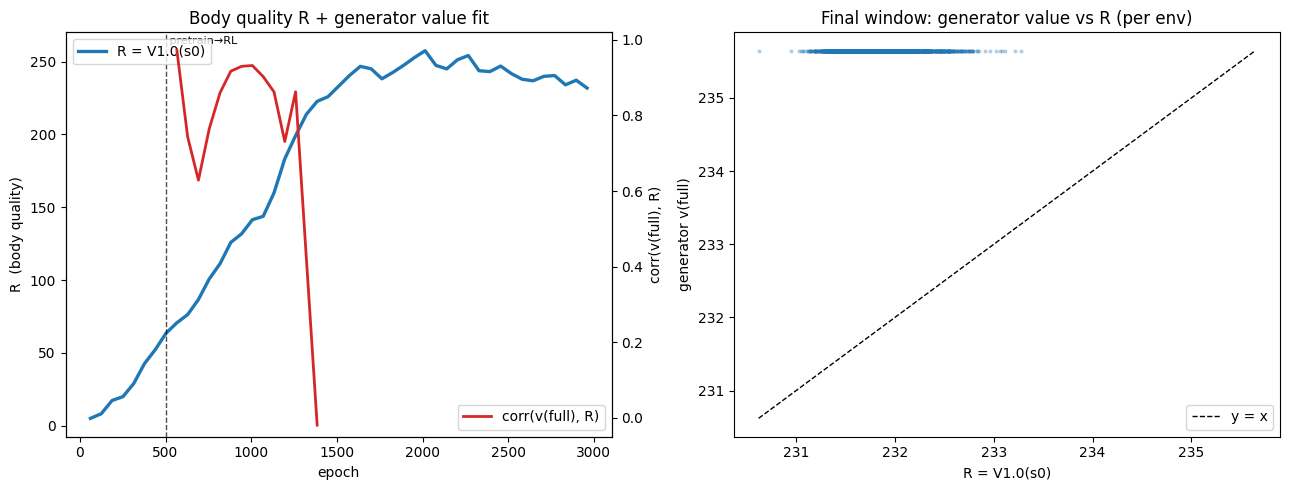

In [16]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))

# A: R over training + value-vs-R fit (twin axis)
band(axA, 'gen/R_mean', color='C0', lw=2.4, label='R = V1.0(s0)')
axA.set(xlabel='epoch', ylabel='R  (body quality)'); axA.legend(loc='upper left')
axA2 = axA.twinx()
band(axA2, 'gen/value_R_corr', color='C3', lw=2.0, label='corr(v(full), R)')
axA2.set_ylabel('corr(v(full), R)'); axA2.set_ylim(-0.05, 1.02); axA2.legend(loc='lower right')
mark_rl(axA); axA.set_title('Body quality R + generator value fit')

# B: final-window per-env scatter v(full) vs R (+ y=x)
S = np.load(Path('../data/ant_codesign/gen_scatter.npz'))
for i, s in enumerate(seeds):
    R, vf = S[f's{s}__R'], S[f's{s}__v_full']
    axB.scatter(R, vf, s=4, alpha=0.25, color=f'C{i}', label=f's{s}' if len(seeds) > 1 else None)
lo = min(R.min(), vf.min()); hi = max(R.max(), vf.max())
axB.plot([lo, hi], [lo, hi], 'k--', lw=1.0, label='y = x')
axB.set(xlabel='R = V1.0(s0)', ylabel='generator v(full)',
        title='Final window: generator value vs R (per env)')
axB.legend(); fig.tight_layout()

## 5. V1.0 calibration — is `R` unbiased?

`R = V1.0(s0)` is only a valid body-quality reward if the V1.0 head's reset-state estimate tracks the
**realized** full-episode return. `v1/v1_s0` (estimate) should overlay `v1/episode_return` (realized),
and `v1/calibration_gap = v1_s0 − episode_return` should hover near 0 (a persistent +gap signals a
truncation-bootstrap leak). This validates the §9 risk in the plan.

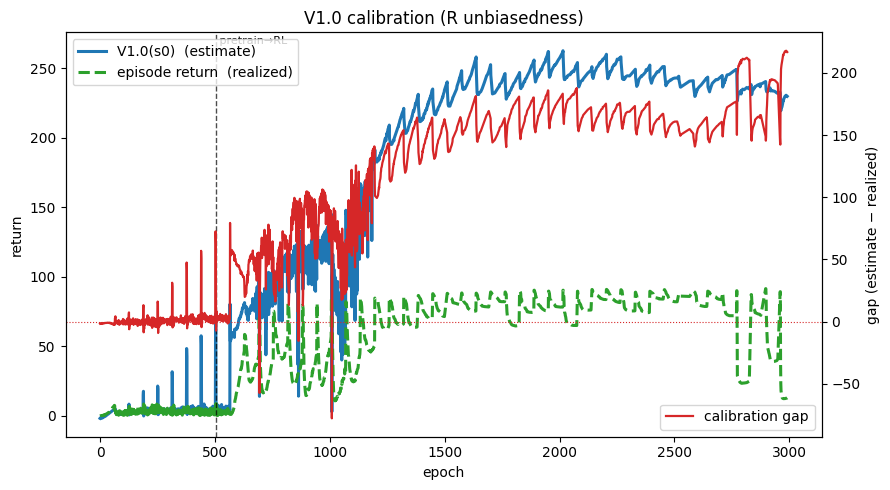

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
band(ax, 'v1/v1_s0', color='C0', lw=2.2, label='V1.0(s0)  (estimate)')
band(ax, 'v1/episode_return', color='C2', lw=2.2, ls='--', label='episode return  (realized)')
ax.set(xlabel='epoch', ylabel='return'); ax.legend(loc='upper left')
ax2 = ax.twinx()
band(ax2, 'v1/calibration_gap', color='C3', lw=1.6, label='calibration gap')
ax2.axhline(0, color='C3', lw=0.8, ls=':'); ax2.set_ylabel('gap (estimate − realized)')
ax2.legend(loc='lower right')
mark_rl(ax); ax.set_title('V1.0 calibration (R unbiasedness)'); fig.tight_layout()

## 6. Control performance (training, all bodies)

`rewards/step` = mean episode reward over all envs each epoch (the col-0 / V0.98 return), i.e. control
skill across the mix of bodies actually being trained on. Raw curve is faint; the bold line is a
one-resample-window rolling mean, which averages out the per-rebuild dips. (Complements the
`R = V1.0(s0)` body-quality curve in §4.)

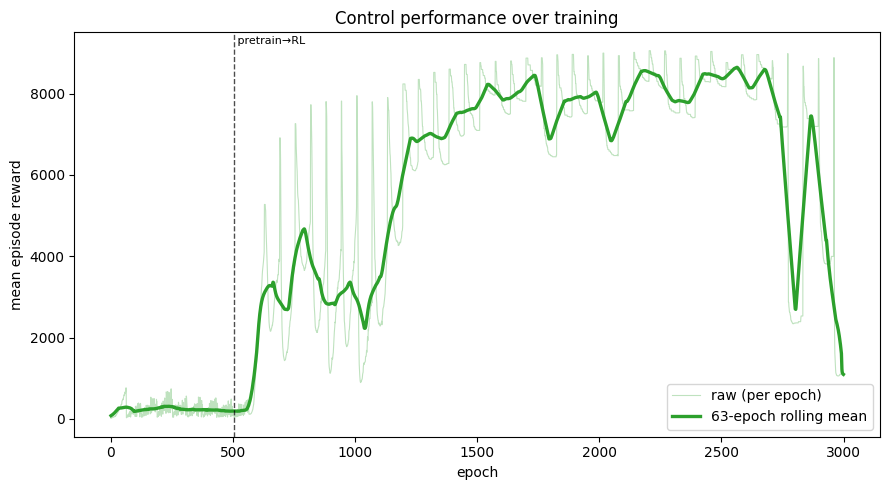

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
band(ax, 'rewards/step', color='C2', lw=0.8, alpha=0.3, label='raw (per epoch)')
band(ax, 'rewards/step', color='C2', lw=2.4, smooth_w=WINDOW_EPOCHS,
     label=f'{WINDOW_EPOCHS}-epoch rolling mean')
ax.set(xlabel='epoch', ylabel='mean episode reward', title='Control performance over training')
mark_rl(ax)
ax.legend(); fig.tight_layout()

## 7. Generator entropy + gen fraction

`gen/entropy` is the mean per-token `{on,stop}` policy entropy; a gentle decline (not a cliff) means no
premature collapse. `gen/fraction` is the pretrain->RL ramp: the share of envs built from the generator
(vs base±flip) per window, climbing 0 -> 1 across the pretrain windows.

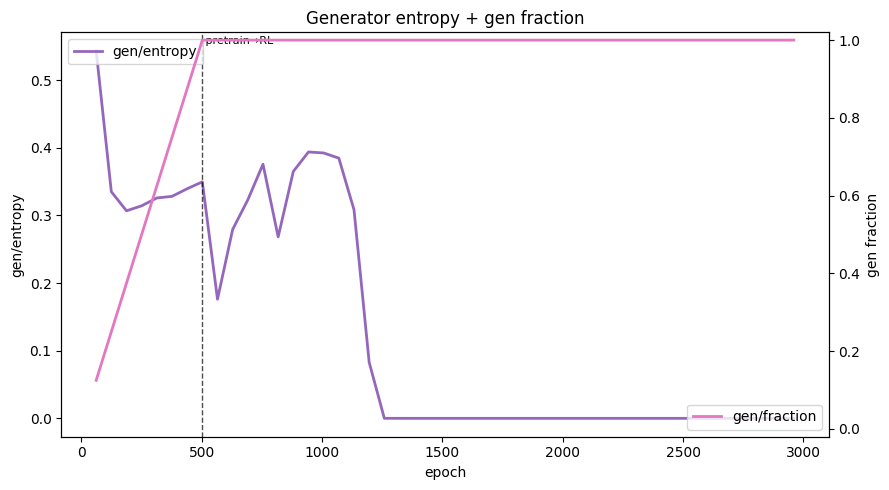

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
band(ax, 'gen/entropy', color='C4', lw=2.0, label='gen/entropy')
ax.set(xlabel='epoch', ylabel='gen/entropy'); ax.legend(loc='upper left')
ax2 = ax.twinx()
band(ax2, 'gen/fraction', color='C6', lw=2.0, label='gen/fraction')
ax2.set_ylabel('gen fraction'); ax2.set_ylim(-0.02, 1.02); ax2.legend(loc='lower right')
mark_rl(ax)
ax.set_title('Generator entropy + gen fraction'); fig.tight_layout()

## 8. Control performance on the BASE morphology

Offline per-checkpoint eval (deterministic mu, raw episode return) on the FIXED base body — isolates
control skill on one body, decoupled from the changing generated bodies. **Rising/flat = base skill
retained; falling = the policy forgets base as it specializes on leggier generated bodies.**

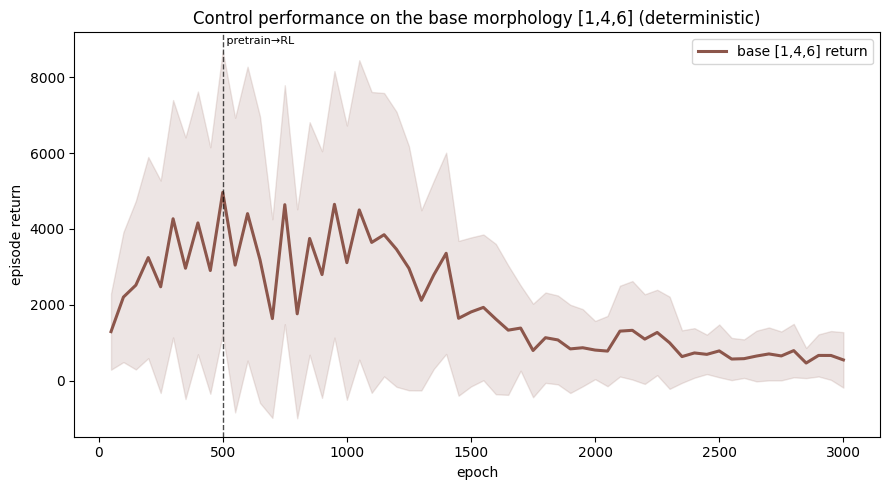

In [20]:
B = np.load(Path('../data/ant_codesign/base_eval.npz'))
base_lbl = '[' + ','.join(str(int(x)) for x in B['base_legs']) + ']'
fig, ax = plt.subplots(figsize=(9, 5))
for i, s in enumerate(seeds):
    ep, mu, sd = B[f's{s}__epoch'], B[f's{s}__ret_mean'], B[f's{s}__ret_std']
    ax.plot(ep, mu, color='C5', lw=2.2, label=f'base {base_lbl} return' if i == 0 else None)
    ax.fill_between(ep, mu - sd, mu + sd, color='C5', alpha=0.15)
ax.set(xlabel='epoch', ylabel='episode return',
       title=f'Control performance on the base morphology {base_lbl} (deterministic)')
mark_rl(ax)
ax.legend(); fig.tight_layout()